# Spectral Element / DG 方法底層運算實作

本筆記本旨在建構與驗證非結構網格（直邊三角形）上的高階數值方法基礎工具，包含參考單元剖分、幾何度量項計算、以及邊界節點提取（Index Mapping）。

## 1. 參考三角形的網格剖分 (Reference Triangle Subdivision)

為了在三角形單元上定義多項式基底與節點，我們首先將頂點為 $(0,0), (1,0), (0,1)$ 的標準參考三角形進行均勻切分。對於給定的邊界劃分數 $N_{div}$，節點座標 $(x_i, y_j)$ 可定義為：
$$x_i = \frac{i}{N_{div}}, \quad y_j = \frac{j}{N_{div}}$$
其中 $0 \le i+j \le N_{div}$。

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def generate_subdivided_triangle(n_div):
    """
    將頂點為 (0,0), (1,0), (0,1) 的參考三角形切分成 n_div^2 個小三角形。
    """
    nodes = []
    # 生成節點座標
    for j in range(n_div + 1):
        for i in range(n_div + 1 - j):
            x = i / n_div
            y = j / n_div
            nodes.append((x, y))
    nodes = np.array(nodes)

    # 建立三角形的連接性 (Connectivity)
    triangles = []
    node_idx = {}
    curr = 0
    for j in range(n_div + 1):
        for i in range(n_div + 1 - j):
            node_idx[(i, j)] = curr
            curr += 1
            
    for j in range(n_div):
        for i in range(n_div - j):
            # 正向三角形
            triangles.append([node_idx[(i, j)], node_idx[(i+1, j)], node_idx[(i, j+1)]])
            # 反向三角形 (填補間隙)
            if i + j + 1 < n_div:
                triangles.append([node_idx[(i+1, j)], node_idx[(i+1, j+1)], node_idx[(i, j+1)]])
                
    return nodes, triangles

def plot_mesh(n_div, title):
    nodes, triangles = generate_subdivided_triangle(n_div)
    plt.figure(figsize=(5, 5))
    for tri in triangles:
        t_nodes = nodes[tri]
        t_plot = np.vstack([t_nodes, t_nodes[0]]) # 閉合三角形
        plt.plot(t_plot[:, 0], t_plot[:, 1], 'b-', linewidth=1)
        plt.fill(t_plot[:, 0], t_plot[:, 1], 'skyblue', alpha=0.3)
    
    plt.scatter(nodes[:, 0], nodes[:, 1], c='red', s=20, label='Nodes')
    plt.title(f"{title}\n(Edge divisions: {n_div})")
    plt.xlabel(r"$\xi$")
    plt.ylabel(r"$\eta$")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.axis('equal')
    plt.legend()
    plt.show()

# 測試繪圖 (取消註解可執行)
# plot_mesh(2, "Level 1 Refinement: [0, 0.5, 1.0]")
# plot_mesh(3, "Level 2 Refinement: [0, 0.33, 0.67, 1]")

## 2. 座標映射與幾何度量項 (Coordinate Mapping and Metrics)

為了在任意物理三角形上進行計算，我們需要定義從參考座標 $(r, s) \in [-1, 1]^2$ 到物理座標 $(x, y)$ 的仿射變換（Affine Transformation）：
$$x(r, s) = x_1 + \frac{x_2 - x_1}{2}(r + 1) + \frac{x_3 - x_1}{2}(s + 1)$$
$$y(r, s) = y_1 + \frac{y_2 - y_1}{2}(r + 1) + \frac{y_3 - y_1}{2}(s + 1)$$

### 2.1 雅可比矩陣 (Jacobian) 與度量項
微積分連鎖律所需的幾何度量項可以透過雅可比行列式 $J$ 轉換：
$$J = \frac{\partial x}{\partial r}\frac{\partial y}{\partial s} - \frac{\partial x}{\partial s}\frac{\partial y}{\partial r} = x_r y_s - x_s y_r$$

對應的逆映射偏導數為：
$$r_x = \frac{y_s}{J}, \quad r_y = -\frac{x_s}{J}, \quad s_x = -\frac{y_r}{J}, \quad s_y = \frac{x_r}{J}$$

### 2.2 散度計算 (Divergence Computation)
根據上述度量，向量場 $\mathbf{F} = (F_x, F_y)$ 的散度在參考座標系中可改寫為：
$$\nabla \cdot \mathbf{F} = \frac{1}{J} \left[ \frac{\partial}{\partial r} (y_s F_x - x_s F_y) + \frac{\partial}{\partial s} (-y_r F_x + x_r F_y) \right]$$

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

# 專案路徑設定
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 若無對應 src 模組，可先將下方 import 註解以防報錯
try:
    from src.core.generators import build_nodes
    from src.core.render_utils import VERTICES_2D, VERTICES_3D
except ImportError:
    pass

def get_reference_data(method: str, k: int):
    nodes = build_nodes(method, k, VERTICES_2D, VERTICES_3D)
    bary_coords = np.array([n.barycentric for n in nodes], dtype=float)
    weights = np.array([n.weight for n in nodes], dtype=float)
    xi = 2.0 * bary_coords[:, 2] - 1.0
    eta = 2.0 * bary_coords[:, 1] - 1.0
    return {
        "nodes": nodes,
        "bary_coords": bary_coords,
        "weights": weights,
        "xi": xi,
        "eta": eta,
    }

def compute_geometric_factors(v1, v2, v3):
    """計算直邊三角形的 Jacobian 與幾何度量項。"""
    x1, y1 = v1
    x2, y2 = v2
    x3, y3 = v3
    
    # 計算偏導數
    xr = (x2 - x1) / 2.0
    yr = (y2 - y1) / 2.0
    xs = (x3 - x1) / 2.0
    ys = (y3 - y1) / 2.0
    
    # 計算 Jacobian
    J = xr * ys - xs * yr
    if np.isclose(J, 0.0):
        raise ValueError("Jacobian為零！請檢查頂點是否共線，或是構成退化三角形。")
        
    # 計算逆矩陣的度量項
    rx = ys / J
    ry = -xs / J
    sx = -yr / J
    sy = xr / J
    
    return {"J": J, "rx": rx, "ry": ry, "sx": sx, "sy": sy, "xr": xr, "yr": yr, "xs": xs, "ys": ys}

def rs_to_xy(r, s, v1, v2, v3):
    """將參考座標 (r, s) 轉換為物理座標 (x, y)。"""
    x1, y1 = v1
    x2, y2 = v2
    x3, y3 = v3
    x = x1 + (x2 - x1) * (r + 1) / 2.0 + (x3 - x1) * (s + 1) / 2.0
    y = y1 + (y2 - y1) * (r + 1) / 2.0 + (y3 - y1) * (s + 1) / 2.0
    return x, y

def compute_divergence(Fx, Fy, factors, D_xi, D_eta):
    """計算向量場 F(x, y) 的散度。"""
    J = factors["J"]
    xs, ys, xr, yr = factors["xs"], factors["ys"], factors["xr"], factors["yr"]

    term_r = ys * Fx - xs * Fy
    term_s = -yr * Fx + xr * Fy
    
    div_F = (D_xi @ term_r + D_eta @ term_s) / J
    return div_F

## 3. 邊界節點提取 (Boundary Node Extraction & Fmask)

在 DG 方法中，數值通量（Numerical Flux）僅在單元交界面上進行計算。因此，我們需要從體積節點 $N_p$ 中提取出表面節點 $N_{fp}$。

三角形的邊界可以利用**重心座標 (Barycentric Coordinates)** $(L_1, L_2, L_3)$ 輕鬆識別：
* **Face 1:** $L_3 = 0$
* **Face 2:** $L_1 = 0$
* **Face 3:** $L_2 = 0$

提取過程可以表示為一個映射矩陣 $E^T \in \mathbb{R}^{N_p \times 3N_{fp}}$，其元素為二元值 $\{0, 1\}$，確保：
$$\mathbf{Q}_{face} = E^T \mathbf{Q}_{volume}$$

--- 映射矩陣 E^T (0/1 表示) ---


,Face1_pt1,Face1_pt2,Face1_pt3,Face1_pt4,Face1_pt5,Face2_pt1,Face2_pt2,Face2_pt3,Face2_pt4,Face2_pt5,Face3_pt1,Face3_pt2,Face3_pt3,Face3_pt4,Face3_pt5
Volume Node,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
6,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
7,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


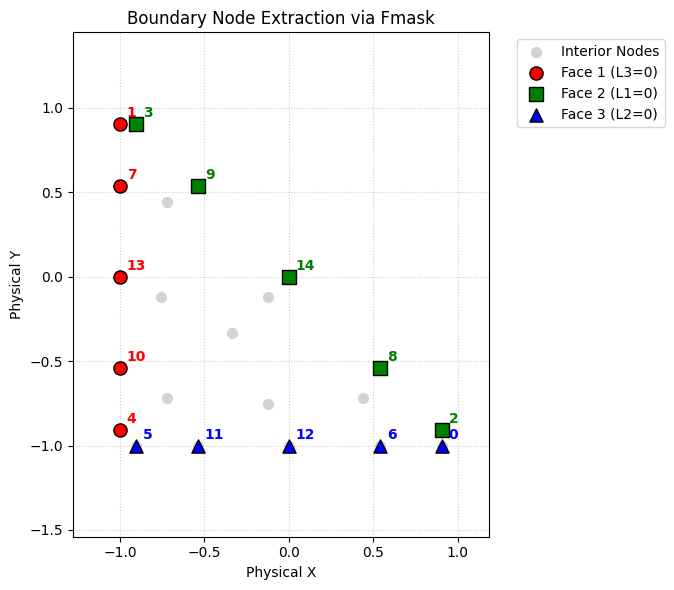

In [3]:
def build_fmask_table1(bary_coords, tol=1e-10):
    """根據重心座標提取邊界點索引 (Fmask)"""
    fmask = []
    # Face 1: L3 = 0
    f1 = np.where(bary_coords[:, 2] < tol)[0]
    fmask.append(f1[np.argsort(bary_coords[f1, 1])])
    
    # Face 2: L1 = 0
    f2 = np.where(bary_coords[:, 0] < tol)[0]
    fmask.append(f2[np.argsort(bary_coords[f2, 2])])
    
    # Face 3: L2 = 0
    f3 = np.where(bary_coords[:, 1] < tol)[0]
    fmask.append(f3[np.argsort(bary_coords[f3, 0])])
    
    return np.column_stack(fmask)

def display_extraction_dataframe(fmask, num_volume_nodes):
    """將 Fmask 展開為 0/1 映射矩陣 E^T 以供檢查。"""
    num_face_nodes = fmask.shape[0]
    E_T = np.zeros((num_volume_nodes, 3 * num_face_nodes), dtype=int)
    
    for face in range(3):
        for local_i, global_idx in enumerate(fmask[:, face]):
            col_idx = face * num_face_nodes + local_i
            E_T[global_idx, col_idx] = 1 
            
    col_names = [f"Face{f+1}_pt{i+1}" for f in range(3) for i in range(num_face_nodes)]
    df = pd.DataFrame(E_T, columns=col_names)
    df.index.name = "Volume Node"
    return df

def plot_extracted_nodes_for_element(x, y, fmask):
    """視覺化單元內部點與邊界點的分佈。"""
    plt.figure(figsize=(7, 6))
    plt.scatter(x, y, c='lightgray', s=50, label='Interior Nodes', zorder=1)
    
    colors, labels, markers = ['red', 'green', 'blue'], ['Face 1 (L3=0)', 'Face 2 (L1=0)', 'Face 3 (L2=0)'], ['o', 's', '^']
    
    for face in range(3):
        face_nodes = fmask[:, face]
        plt.scatter(x[face_nodes], y[face_nodes], c=colors[face], s=90, 
                    marker=markers[face], edgecolor='black', label=labels[face], zorder=2)
        for idx in face_nodes:
            plt.annotate(str(idx), (x[idx], y[idx]), xytext=(5, 5), textcoords='offset points', 
                         fontsize=10, color=colors[face], fontweight='bold')
            
    plt.title("Boundary Node Extraction via Fmask")
    plt.xlabel("Physical X")
    plt.ylabel("Physical Y")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.axis('equal')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

# 測試與執行區塊 (若有正確導入 reference_data 模組即可運行)
if 'get_reference_data' in locals() and 'build_nodes' in locals():
    ref_data = get_reference_data("table1", 4)
    bary_coords = ref_data["bary_coords"]
    fmask = build_fmask_table1(bary_coords)
    
    print("--- 映射矩陣 E^T (0/1 表示) ---")
    df_extraction = display_extraction_dataframe(fmask, bary_coords.shape[0])
    # 解決 pandas 新版警告：使用 map 代替 applymap
    display(df_extraction.style.map(lambda x: 'background-color: yellow' if x == 1 else 'color: lightgray'))
    plot_extracted_nodes_for_element(ref_data["xi"], ref_data["eta"], fmask)

## 4. 全域張量的高效邊界提取 (Global Tensor Extraction)

在實際的流體力學求解器中，我們需要處理包含多個物理變數、所有節點與全部網格單元的三維狀態矩陣 $\mathbf{Q} \in \mathbb{R}^{N_{var} \times N_p \times K}$（其中 $K$ 為元素總數）。

透過將 `Fmask` 以 Column-major (Fortran-order) 攤平為一維陣列，我們可以使用 NumPy 的高級索引 (Advanced Indexing)，以無迴圈 (Vectorized) 的方式，一口氣將全域的邊界狀態矩陣提取出來：
$$\mathbf{Q}_{face} \in \mathbb{R}^{N_{var} \times 3N_{fp} \times K}$$

In [4]:
def test_global_boundary_extraction(fmask, num_volume_nodes):
    n_var = 2           # 模擬 2 個物理變數
    num_elements = 4    # 模擬 4 個小三角形
    Np = num_volume_nodes
    num_face_nodes = fmask.shape[0]
    
    print("模擬環境設定:")
    print(f"變數數量 (n_var): {n_var} | 單一元素節點數 (Np): {Np} | 總元素數量 (num_elements): {num_elements}")
    print("-" * 50)

    # 建立模擬狀態矩陣 Q (變數編號*1000 + 節點編號*10 + 元素編號)
    Q = np.zeros((n_var, Np, num_elements), dtype=int)
    for v in range(n_var):
        for n in range(Np):
            for k in range(num_elements):
                Q[v, n, k] = v * 1000 + n * 10 + k

    print(f"建立全域狀態矩陣 Q，形狀: {Q.shape}")

    # --- 核心提取邏輯 ---
    # 將 fmask (N_fp x 3) 攤平為 1D 索引陣列，確保順序是 Face1 -> Face2 -> Face3
    flat_fmask = fmask.flatten(order='F')
    
    # 透過 NumPy 高級索引，一次取出所有邊界點
    Q_face = Q[:, flat_fmask, :]
    
    print(f"提取後的邊界矩陣 Q_face，形狀: {Q_face.shape} (期望: ({n_var}, {3 * num_face_nodes}, {num_elements}))")
    print("-" * 50)

    # 驗證提取結果
    extracted_values = Q_face[0, :, 0] 
    original_node_indices = extracted_values // 10
    
    face_labels = [f"Face {f+1}" for f in range(3) for _ in range(num_face_nodes)]
    df_check = pd.DataFrame({
        "所屬邊界": face_labels,
        "提取出的值 (Q_face)": extracted_values,
        "還原對應的節點編號": original_node_indices,
        "Fmask 中紀錄的編號": flat_fmask
    })
    
    is_match = np.all(original_node_indices == flat_fmask)
    print(f"提取正確性檢查結果: {'✅ 完美吻合' if is_match else '❌ 有錯誤'}")
    
    return df_check

# 執行測試 (若 fmask 已定義即可運行)
if 'fmask' in locals() and 'bary_coords' in locals():
    df_check = test_global_boundary_extraction(fmask, bary_coords.shape[0])
    display(df_check)

模擬環境設定:
變數數量 (n_var): 2 | 單一元素節點數 (Np): 22 | 總元素數量 (num_elements): 4
--------------------------------------------------
建立全域狀態矩陣 Q，形狀: (2, 22, 4)
提取後的邊界矩陣 Q_face，形狀: (2, 15, 4) (期望: (2, 15, 4))
--------------------------------------------------
提取正確性檢查結果: ✅ 完美吻合


,所屬邊界,提取出的值 (Q_face),還原對應的節點編號,Fmask 中紀錄的編號
0,Face 1,40,4,4
1,Face 1,100,10,10
2,Face 1,130,13,13
3,Face 1,70,7,7
4,Face 1,10,1,1
5,Face 2,30,3,3
6,Face 2,90,9,9
7,Face 2,140,14,14
8,Face 2,80,8,8
9,Face 2,20,2,2
